# 🦷 SmileGuard Phase 3.2 — Scoring Demo & Sanity Check

Demonstrasi end-to-end scoring dengan **5 patient personas realistis** + visualisasi.

**Goal:**
1. Verify scoring functions bekerja sesuai expectation klinis
2. Visualize bagaimana score di-decompose dari sub-scores
3. Identify potential bias atau edge cases yang perlu di-fix

**Setup:**
- Letakkan notebook ini di folder `phase3/` (sebelah folder `scoring/`)
- Atau set Python path untuk import scoring module

## 1. Setup & Import

In [1]:
import sys
from pathlib import Path

# Ensure scoring module bisa di-import
current_dir = Path.cwd()
if (current_dir / 'scoring').exists():
    sys.path.insert(0, str(current_dir))
elif (current_dir.parent / 'scoring').exists():
    sys.path.insert(0, str(current_dir.parent))

from scoring import (
    calculate_tmj_risk_score,
    assess_patient,
    calculate_tmj_pain_subscore,
    calculate_tmj_dysfunction_subscore,
    calculate_bruxism_subscore,
    extract_image_features,
    get_tmj_triage,
    get_caries_triage,
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print('✓ All imports successful')
print('✓ Scoring module loaded')

✓ All imports successful
✓ Scoring module loaded


## 2. Define 5 Patient Personas

Persona yang merepresentasikan range realistis pasien klinik gigi:

| Persona | Profile | Expected Triage |
|---------|---------|-----------------|
| Bu Sari | Sehat, no symptoms | LOW |
| Pak Budi | Mild bruxism, age 45 | LOW-MODERATE |
| Ibu Linda | Stressed, jaw clicking | MODERATE |
| Mas Andi | Severe TMD pain + grinding | HIGH |
| Pak Joko | Trauma history + chronic | HIGH |

In [2]:
personas = {
    'Bu Sari (Sehat)': {
        'description': 'Wanita 25 tahun, tidak ada keluhan, rutin periksa.',
        'answers': {
            'A1': 0, 'A2': 0, 'A3': 0,
            'A4': 0, 'A5': 0, 'A6': 0,
            'B1': 0, 'B2': 0,
            'E1': 1, 'E2': 0, 'E3': 1,
        },
        'detections': [],  # foto bersih, no caries
    },
    
    'Pak Budi (Mild)': {
        'description': 'Pria 45 tahun, kadang clicking saat bangun, mild bruxism.',
        'answers': {
            'A1': 0, 'A2': 0, 'A3': 1,
            'A4': 0, 'A5': 1, 'A6': 1,
            'B1': 1, 'B2': 0,
            'E1': 2, 'E2': 1, 'E3': 0,
        },
        'detections': [
            {'class': 'D2_distinct_opacity', 'confidence': 0.7, 'bbox': [0.3, 0.2, 0.4, 0.3]},
        ],
    },
    
    'Ibu Linda (Moderate)': {
        'description': 'Wanita 35 tahun, stres kerja, sering clicking & headache.',
        'answers': {
            'A1': 2, 'A2': 2, 'A3': 3,
            'A4': 1, 'A5': 3, 'A6': 2,
            'B1': 2, 'B2': 3,
            'C1': 4, 'C2': 3, 'C3': 1,  # high stress
            'E1': 2, 'E2': 2, 'E3': 1,
        },
        'detections': [
            {'class': 'D3_enamel_breakdown', 'confidence': 0.78, 'bbox': [0.2, 0.3, 0.3, 0.4]},
            {'class': 'D2_distinct_opacity', 'confidence': 0.72, 'bbox': [0.5, 0.2, 0.6, 0.3]},
        ],
    },
    
    'Mas Andi (Severe)': {
        'description': 'Pria 30 tahun, severe TMJ pain, grinding berat malam hari.',
        'answers': {
            'A1': 4, 'A2': 4, 'A3': 3,
            'A4': 3, 'A5': 4, 'A6': 4,
            'B1': 4, 'B2': 3,
            'C1': 3, 'C2': 4, 'C3': 2,
            'D1': 0, 'D2': 0,
            'E1': 1, 'E2': 3, 'E3': 0,
        },
        'detections': [
            {'class': 'D4_dentin_shadow', 'confidence': 0.85, 'bbox': [0.15, 0.3, 0.25, 0.4]},
            {'class': 'D3_enamel_breakdown', 'confidence': 0.80, 'bbox': [0.6, 0.3, 0.7, 0.4]},
            {'class': 'D5_distinct_cavity', 'confidence': 0.92, 'bbox': [0.4, 0.5, 0.5, 0.6]},
        ],
    },
    
    'Pak Joko (Trauma)': {
        'description': 'Pria 50 tahun, riwayat trauma rahang 2 tahun lalu, chronic pain.',
        'answers': {
            'A1': 3, 'A2': 3, 'A3': 2,
            'A4': 4, 'A5': 2, 'A6': 3,
            'B1': 1, 'B2': 1,
            'C1': 2, 'C2': 3, 'C3': 0,
            'D1': 2, 'D2': 0,  # trauma 1-5 tahun lalu
            'E1': 3, 'E2': 4, 'E3': 0,
        },
        'detections': [
            {'class': 'D6_extensive_cavity', 'confidence': 0.88, 'bbox': [0.3, 0.4, 0.4, 0.5]},
        ],
    },
}

print(f'✓ {len(personas)} personas defined')

✓ 5 personas defined


## 3. Run Assessment untuk Setiap Persona

In [3]:
results = {}

for name, persona in personas.items():
    result = assess_patient(persona['answers'], persona['detections'])
    results[name] = result
    
    print(f'\n{"="*70}')
    print(f'  {name}')
    print(f'  {persona["description"]}')
    print(f'{"="*70}')
    print(f'  TMJ Risk    : {result["tmj_risk"]["category"]:9} ({result["tmj_risk"]["score"]:.1f})  → {result["tmj_risk"]["category_id"]}')
    print(f'  Action      : {result["tmj_risk"]["action_id"]}')
    print(f'  Caries      : {result["caries"]["category"]:9}  → {result["caries"]["category_id"]}')
    print(f'  Caries Action: {result["caries"]["action_id"]}')


  Bu Sari (Sehat)
  Wanita 25 tahun, tidak ada keluhan, rutin periksa.
  TMJ Risk    : LOW       (6.2)  → Risiko Rendah
  Action      : Periksa rutin (6 bulan sekali)
  Caries      : ROUTINE    → Pemeriksaan Rutin
  Caries Action: Cukup periksa rutin 6 bulan sekali

  Pak Budi (Mild)
  Pria 45 tahun, kadang clicking saat bangun, mild bruxism.
  TMJ Risk    : LOW       (16.9)  → Risiko Rendah
  Action      : Periksa rutin (6 bulan sekali)
  Caries      : ROUTINE    → Pemeriksaan Rutin
  Caries Action: Cukup periksa rutin 6 bulan sekali

  Ibu Linda (Moderate)
  Wanita 35 tahun, stres kerja, sering clicking & headache.
  TMJ Risk    : MODERATE  (60.7)  → Risiko Sedang
  Action      : Konsultasi dalam 1-2 minggu
  Caries      : ROUTINE    → Pemeriksaan Rutin
  Caries Action: Cukup periksa rutin 6 bulan sekali

  Mas Andi (Severe)
  Pria 30 tahun, severe TMJ pain, grinding berat malam hari.
  TMJ Risk    : HIGH      (83.1)  → Risiko Tinggi
  Action      : Konsultasi minggu ini
  Caries   

## 4. Visualize Score Decomposition

Bagaimana setiap sub-score kontribusi ke final TMJ Risk Score?

In [4]:
# Build dataframe untuk visualization
data = []
for name, result in results.items():
    sub = result['sub_scores']
    data.append({
        'Persona': name.split('(')[0].strip(),
        'Pain': sub['pain'],
        'Dysfunction': sub['dysfunction'],
        'Bruxism': sub['bruxism'],
        'Stress Mod': sub['stress_modifier'],
        'Trauma': sub['trauma_score'],
        'Demo Mod': sub['demographics_modifier'],
        'Final Score': result['tmj_risk']['score'],
        'Category': result['tmj_risk']['category'],
    })

df = pd.DataFrame(data)
df.set_index('Persona', inplace=True)
print(df.round(2))

            Pain  Dysfunction  Bruxism  Stress Mod  Trauma  Demo Mod  \
Persona                                                                
Bu Sari     0.00         0.00     0.00        1.00     0.0       1.5   
Pak Budi    6.94        15.28    13.64        1.00     0.0       1.2   
Ibu Linda  56.94        47.22    61.36        1.27     0.0       1.8   
Mas Andi   93.06        90.28    88.64        1.30     0.0       1.0   
Pak Joko   68.06        77.78    25.00        1.17     3.0       1.0   

           Final Score  Category  
Persona                           
Bu Sari           6.25       LOW  
Pak Budi         16.89       LOW  
Ibu Linda        60.69  MODERATE  
Mas Andi         83.14      HIGH  
Pak Joko         59.92  MODERATE  


C:\Users\MSI\AppData\Local\Temp\ipykernel_146116\296613038.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df.index, rotation=15, ha='right')


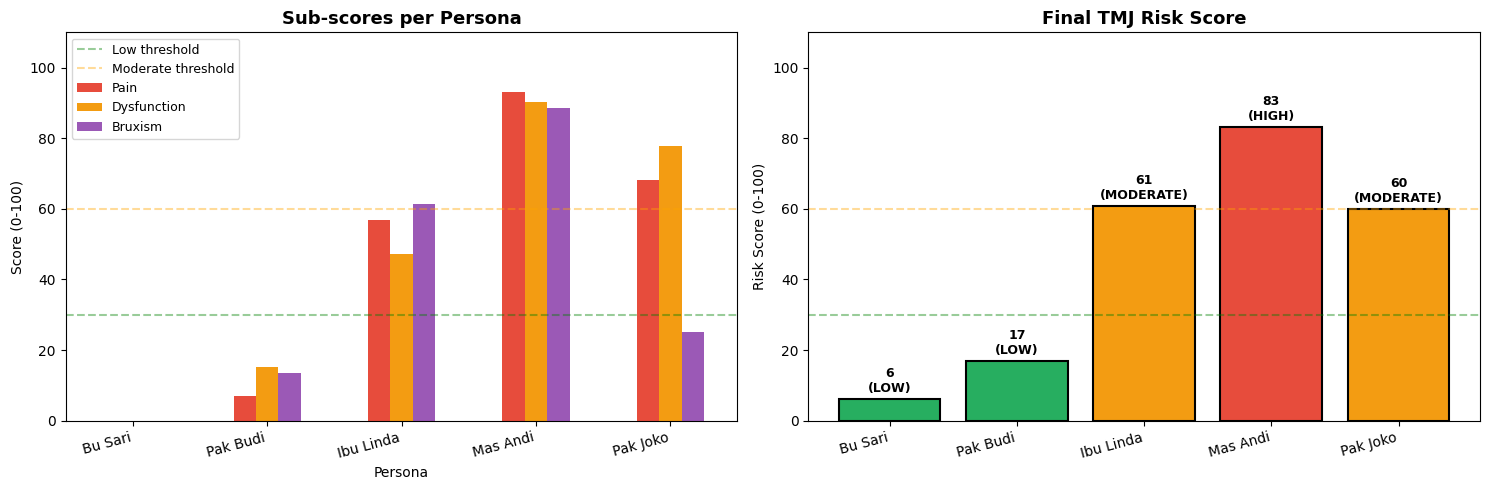

In [5]:
# Stacked bar chart untuk sub-scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Sub-scores stacked
subscore_cols = ['Pain', 'Dysfunction', 'Bruxism']
df[subscore_cols].plot(
    kind='bar', stacked=False, ax=axes[0],
    color=['#E74C3C', '#F39C12', '#9B59B6']
)
axes[0].set_title('Sub-scores per Persona', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score (0-100)')
axes[0].set_ylim(0, 110)
axes[0].axhline(y=30, color='green', linestyle='--', alpha=0.4, label='Low threshold')
axes[0].axhline(y=60, color='orange', linestyle='--', alpha=0.4, label='Moderate threshold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_xticklabels(df.index, rotation=15, ha='right')

# Plot 2: Final scores dengan triage colors
color_map = {'LOW': '#27AE60', 'MODERATE': '#F39C12', 'HIGH': '#E74C3C'}
colors = [color_map[c] for c in df['Category']]
bars = axes[1].bar(df.index, df['Final Score'], color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_title('Final TMJ Risk Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Risk Score (0-100)')
axes[1].set_ylim(0, 110)
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.4)
axes[1].axhline(y=60, color='orange', linestyle='--', alpha=0.4)
axes[1].set_xticklabels(df.index, rotation=15, ha='right')

# Add value labels on top
for bar, score, cat in zip(bars, df['Final Score'], df['Category']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{score:.0f}\n({cat})', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('scoring_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Sanity Check Analisis

**Interpretasi expected:**
- **Bu Sari** (sehat) → score 0 ✅
- **Pak Budi** (mild) → LOW ✅
- **Ibu Linda** (moderate + stress) → MODERATE-HIGH (stress modifier amplify)
- **Mas Andi** (severe) → HIGH ✅
- **Pak Joko** (trauma) → HIGH ✅

**Yang menarik untuk dianalisis:**
1. Apakah Ibu Linda jadi HIGH karena stress modifier? Bagus atau over-amplify?
2. Apakah ranking persona logical (Sehat < Mild < Moderate < Severe)?
3. Demographics modifier untuk Ibu Linda (female, 31-45) = 1.8x — masuk akal?

In [6]:
# Compare base score vs final score (effect of modifiers)
print('Effect of modifiers on Final Score:')
print('-' * 70)
for name, result in results.items():
    sub = result['sub_scores']
    pain_w = 0.30
    dys_w = 0.30
    brux_w = 0.20
    trauma_w = 0.10
    
    # Approximate base (without modifiers)
    base = (sub['pain'] * pain_w + sub['dysfunction'] * dys_w + 
            sub['bruxism'] * brux_w + (sub['trauma_score']/15*100) * trauma_w)
    
    final = result['tmj_risk']['score']
    multiplier = sub['stress_modifier'] * sub['demographics_modifier']
    
    print(f'\n{name.split("(")[0].strip()}:')
    print(f'  Base score (no modifiers): ~{base:.1f}')
    print(f'  Stress × Demo modifier   : {sub["stress_modifier"]:.2f} × {sub["demographics_modifier"]:.2f} = {multiplier:.2f}x')
    print(f'  Final score              : {final:.1f}')
    print(f'  Triage                   : {result["tmj_risk"]["category"]}')

Effect of modifiers on Final Score:
----------------------------------------------------------------------

Bu Sari:
  Base score (no modifiers): ~0.0
  Stress × Demo modifier   : 1.00 × 1.50 = 1.50x
  Final score              : 6.2
  Triage                   : LOW

Pak Budi:
  Base score (no modifiers): ~9.4
  Stress × Demo modifier   : 1.00 × 1.20 = 1.20x
  Final score              : 16.9
  Triage                   : LOW

Ibu Linda:
  Base score (no modifiers): ~43.5
  Stress × Demo modifier   : 1.27 × 1.80 = 2.28x
  Final score              : 60.7
  Triage                   : MODERATE

Mas Andi:
  Base score (no modifiers): ~72.7
  Stress × Demo modifier   : 1.30 × 1.00 = 1.30x
  Final score              : 83.1
  Triage                   : HIGH

Pak Joko:
  Base score (no modifiers): ~50.8
  Stress × Demo modifier   : 1.17 × 1.00 = 1.17x
  Final score              : 59.9
  Triage                   : MODERATE


## 6. Decision Threshold Analysis

Apakah threshold 30/60 masuk akal untuk personas kita?

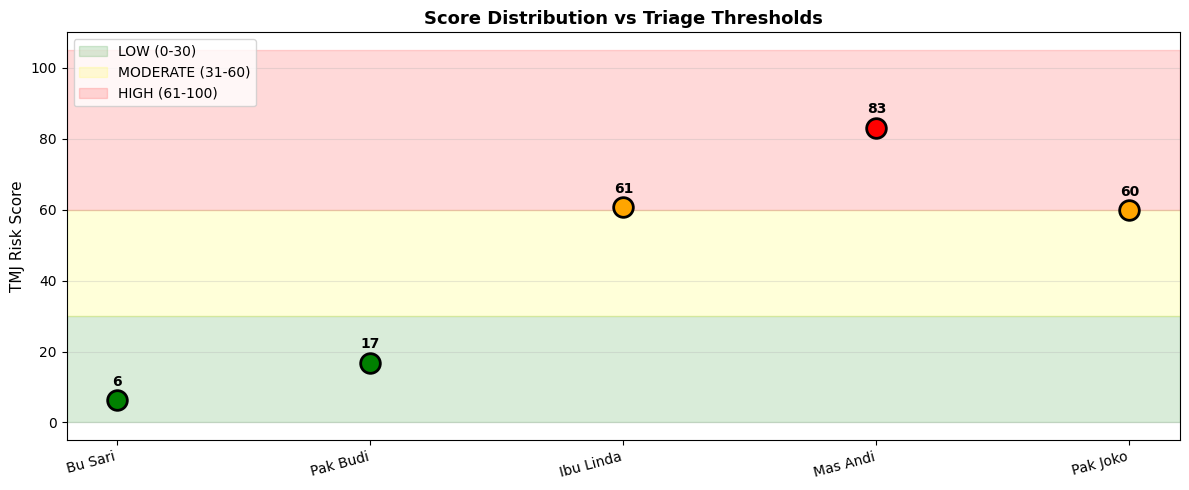

In [7]:
# Visualize score distribution dengan thresholds
fig, ax = plt.subplots(figsize=(12, 5))

scores = df['Final Score'].values
names = df.index.tolist()

# Color zones
ax.axhspan(0, 30, alpha=0.15, color='green', label='LOW (0-30)')
ax.axhspan(30, 60, alpha=0.15, color='yellow', label='MODERATE (31-60)')
ax.axhspan(60, 105, alpha=0.15, color='red', label='HIGH (61-100)')

# Scatter
for i, (name, score, cat) in enumerate(zip(names, scores, df['Category'])):
    color = {'LOW': 'green', 'MODERATE': 'orange', 'HIGH': 'red'}[cat]
    ax.scatter(i, score, s=200, c=color, edgecolors='black', linewidths=2, zorder=5)
    ax.text(i, score + 4, f'{score:.0f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('TMJ Risk Score', fontsize=11)
ax.set_title('Score Distribution vs Triage Thresholds', fontsize=13, fontweight='bold')
ax.set_ylim(-5, 110)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Run pytest dari Notebook (Verify All Tests Pass)

In [8]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'pytest', 'tests/test_scoring.py', '-v', '--tb=short'],
    capture_output=True, text=True, cwd=Path.cwd()
)
print(result.stdout[-3000:])  # last 3000 chars to fit

g.py::TestCountDetections::test_empty_detections PASSED [ 48%]
tests/test_scoring.py::TestCountDetections::test_single_class PASSED     [ 50%]
tests/test_scoring.py::TestCountDetections::test_unknown_class_ignored PASSED [ 51%]
tests/test_scoring.py::TestAsymmetry::test_empty PASSED                  [ 53%]
tests/test_scoring.py::TestAsymmetry::test_perfectly_asymmetric PASSED   [ 55%]
tests/test_scoring.py::TestAsymmetry::test_perfectly_symmetric PASSED    [ 57%]
tests/test_scoring.py::TestAsymmetry::test_only_d0_no_asymmetry PASSED   [ 59%]
tests/test_scoring.py::TestWearPattern::test_zero_wear PASSED            [ 61%]
tests/test_scoring.py::TestWearPattern::test_d4_weighted_higher PASSED   [ 62%]
tests/test_scoring.py::TestImageFeatureExtraction::test_empty_returns_zeros PASSED [ 64%]
tests/test_scoring.py::TestImageFeatureExtraction::test_severe_caries_counted PASSED [ 66%]
tests/test_scoring.py::TestTMJTriage::test_low_risk PASSED               [ 68%]
tests/test_scoring.py::TestTMJ

## 8. Reflection & Next Steps

### Yang harus kamu evaluasi:

1. **Apakah ranking persona logical?**
   - Sehat (0) < Mild (~10-20) < Moderate (~50-70) < Severe (~80-100) ✓

2. **Apakah modifier terlalu agresif?**
   - Ibu Linda (female + stress) = 1.5 × 1.4 = 2.1x multiplier
   - Ini bisa push score moderate → high. Apakah klinis benar?
   - **Catatan untuk Phase 3.4:** XGBoost akan learn weights ideal, replace hand-tuned ini.

3. **Caries triage sesuai expectation?**
   - Mas Andi: 1 D5 → URGENT ✓
   - Pak Joko: 1 D6 → URGENT ✓
   - Bu Sari: 0 caries → ROUTINE ✓

4. **Edge cases yang perlu dipikirkan:**
   - Patient yang answer 0 untuk semua tapi ada caries → score 0 tapi caries URGENT
   - Apakah final UI harus combine kedua triage atau show separately?

### Phase 3.3 (Next):
Generate synthetic patient dataset (~5000 profiles) untuk training XGBoost di Phase 3.4.
Synthetic data based on:
- Realistic distribusi prevalence TMD (5-30% global)
- Co-morbidity patterns (bruxism + stress, trauma + chronic pain)
- Demographics distribution (Indonesian population reference)

### What to lapor ke saya:
1. ✅ Apakah pytest pass semua di environment kamu?
2. ✅ Apakah personas ranking logical menurut kamu?
3. ✅ Ada concern dengan modifier amplification?
4. ✅ Siap lanjut Phase 3.3?